# 03 — Regional retail ↔ wholesale experiment

Does matching EIA weekly retail geography to the relevant daily gasoline hub beat the national weekly model?

**Not production. No trees. No holdout tuning.** Ridge α = 1.0 and δ = $0.03 are frozen from exp01. Holdout cutoff is the same Tuesday: 2016-07-19.

Full write-up: `reports/regional_experiment.md`. The first-model report was not modified.


In [1]:
from pathlib import Path
import sys

import matplotlib
matplotlib.use("Agg")
import pandas as pd

ROOT = Path.cwd()
if (ROOT / "src" / "modeling").exists():
    pass
elif (ROOT / "gas_wait" / "src" / "modeling").exists():
    ROOT = ROOT / "gas_wait"
elif (ROOT / "notebooks").exists() and (ROOT.parent / "src" / "modeling").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from modeling.regional_config import SKIPPED_GEOGRAPHIES, VIABLE_REGIONS, NATIONAL_HOLDOUT_CUTOFF

coverage = pd.read_csv(ROOT / "data" / "processed" / "eia_weekly_regular_retail_coverage.csv")
print("geographies", len(coverage))
print("holdout cutoff", NATIONAL_HOLDOUT_CUTOFF)
coverage.sort_values(["start", "duoarea"])


geographies 29
holdout cutoff 2016-07-19
   duoarea                 area-name     n  n_missing       start         end
0      NUS                      U.S.  1885          6  1990-08-20  2026-08-17
1      R10                    PADD 1  1789          0  1992-05-11  2026-08-17
2      R20                    PADD 2  1789          0  1992-05-11  2026-08-17
3      R30                    PADD 3  1785          0  1992-05-11  2026-08-17
4      R40                    PADD 4  1789          0  1992-05-11  2026-08-17
5      R50                    PADD 5  1785          0  1992-05-11  2026-08-17
6      R1X                   PADD 1A  1743          0  1993-04-05  2026-08-17
7      R1Y                   PADD 1B  1740          0  1993-04-05  2026-08-17
8      R1Z                   PADD 1C  1736          0  1993-04-05  2026-08-17
9    R5XCA  PADD 5 EXCEPT CALIFORNIA  1469          0  1998-05-18  2026-08-17
10     SCA                CALIFORNIA  1372          0  2000-05-22  2026-08-17
11     SCO             

## Viable maps vs skipped geographies


In [2]:
maps = pd.DataFrame(
    [
        {
            "region": r.label,
            "retail_duoarea": r.retail.facets["duoarea"][0],
            "matched_hub": r.matched_hub.geographic_area,
            "mismatch_control": r.mismatched_hub.geographic_area,
        }
        for r in VIABLE_REGIONS
    ]
)
skipped = pd.DataFrame(list(SKIPPED_GEOGRAPHIES))
maps


                                      region retail_duoarea      matched_hub mismatch_control
0                  New York City → NY Harbor          Y35NY  New York Harbor  U.S. Gulf Coast
1     Central Atlantic (PADD 1B) → NY Harbor            R1Y  New York Harbor  U.S. Gulf Coast
2              Houston → Gulf Coast gasoline          Y44HO  U.S. Gulf Coast  New York Harbor
3  Gulf Coast (PADD 3) → Gulf Coast gasoline            R30  U.S. Gulf Coast  New York Harbor
4                      Los Angeles → LA RBOB          Y05LA  Los Angeles, CA  New York Harbor
5                       California → LA RBOB            SCA  Los Angeles, CA  New York Harbor


In [3]:
skipped


   duoarea                        name                                                                                                                         reason
0      R10           PADD 1 East Coast    Mixes Harbor-priced 1A/1B with Lower Atlantic barrels that arrive on Colonial from the Gulf. Not a single wholesale market.
1      R1X         PADD 1A New England                        NY Harbor is the right wholesale, but NYC/PADD 1B are tighter. Skipped to keep the Northeast set small.
2      R1Z      PADD 1C Lower Atlantic  Supplied northbound on Colonial from the Gulf, not NY Harbor. Do not map to Harbor. Gulf Coast is origin, not the local rack.
3     YMIA                       Miami                       Lower Atlantic destination with local blend/tax effects. Gulf Coast spot is only a distant origin proxy.
4      R50           PADD 5 West Coast                           Blends California CARB with WA/OR/AZ/NV/AK/HI conventional/other specs. LA RBOB is not this average.
5   

## Holdout metrics (precomputed regional datasets)


In [4]:
from modeling.evaluate import PRIMARY_DELTA, decision_metrics, regression_metrics
from modeling.run_regional_experiment import MODEL_LABELS, split_at_cutoff, fit_region
from modeling.build_regional_features import build_regional_dataset

rows = []
for region in VIABLE_REGIONS:
    built = build_regional_dataset(region)
    split = split_at_cutoff(built.frame)
    holdout = fit_region(split)
    y = split.test["target"]
    matched = regression_metrics(y, holdout["ridge_matched"].predictions)
    mom = regression_metrics(y, holdout["momentum_baseline"].predictions)
    mis = regression_metrics(y, holdout["ridge_mismatched"].predictions)
    dec = decision_metrics(y, holdout["ridge_matched"].predictions, PRIMARY_DELTA)
    rows.append(
        {
            "region": region.label,
            "n_test": int(matched["n"]),
            "mom_mae": mom["mae"],
            "matched_mae": matched["mae"],
            "mismatch_mae": mis["mae"],
            "mom_dir": mom["directional_accuracy"],
            "matched_dir": matched["directional_accuracy"],
            "matched_r2": matched["r2"],
            "wait": int(dec["n_wait"]),
            "fill": int(dec["n_fill"]),
            "pct_silent": dec["pct_no_signal"],
        }
    )
pd.DataFrame(rows).set_index("region")


                                           n_test   mom_mae  matched_mae  mismatch_mae   mom_dir  matched_dir  matched_r2  wait  fill  pct_silent
region                                                                                                                                           
New York City → NY Harbor                     525  0.040750     0.031495      0.033038  0.709865     0.762089    0.398024    87   118    0.609524
Central Atlantic (PADD 1B) → NY Harbor        525  0.037149     0.027278      0.029186  0.692456     0.775629    0.438224    86   113    0.620952
Houston → Gulf Coast gasoline                 521  0.043971     0.035087      0.033387  0.673114     0.746615    0.349147   101   128    0.560461
Gulf Coast (PADD 3) → Gulf Coast gasoline     525  0.057832     0.041510      0.040230  0.574713     0.712644    0.339694   103   126    0.563810
Los Angeles → LA RBOB                         525  0.050465     0.044082      0.043980  0.741811     0.757225    0.450601   

## Charts


reports/figures/regional_mae_by_region.png
reports/figures/regional_diracc_by_region.png
reports/figures/regional_passthrough_corr.png


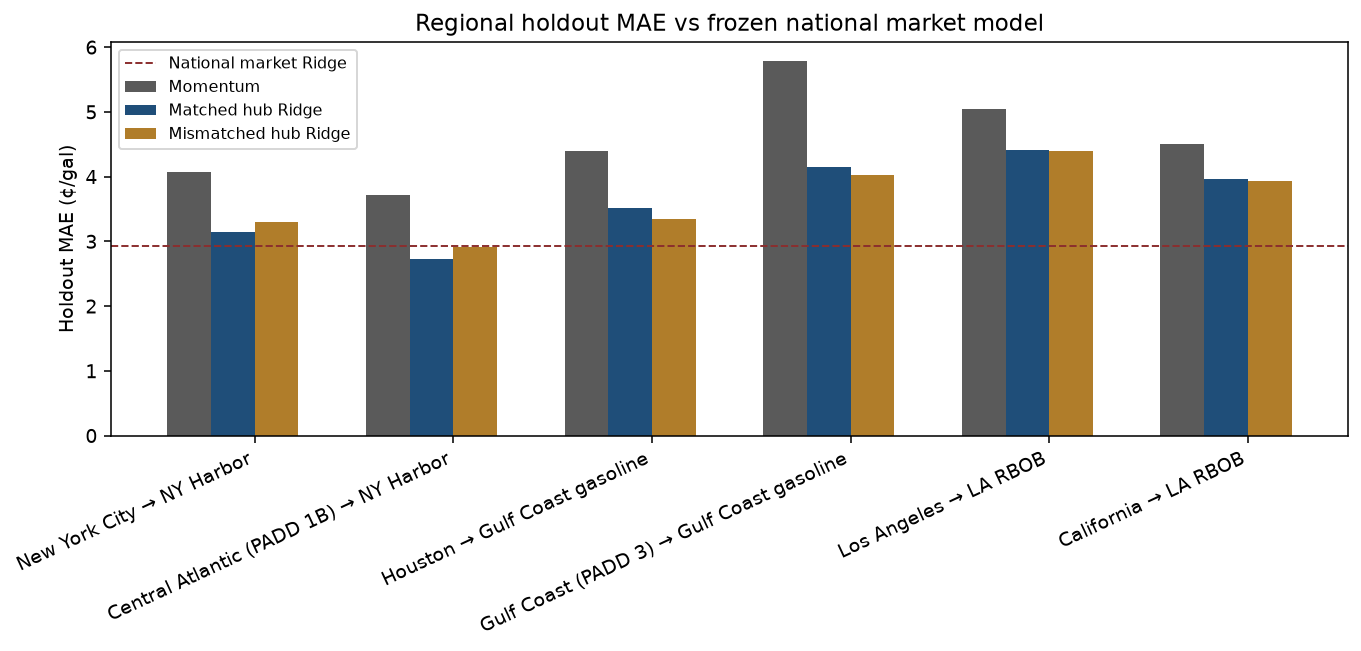

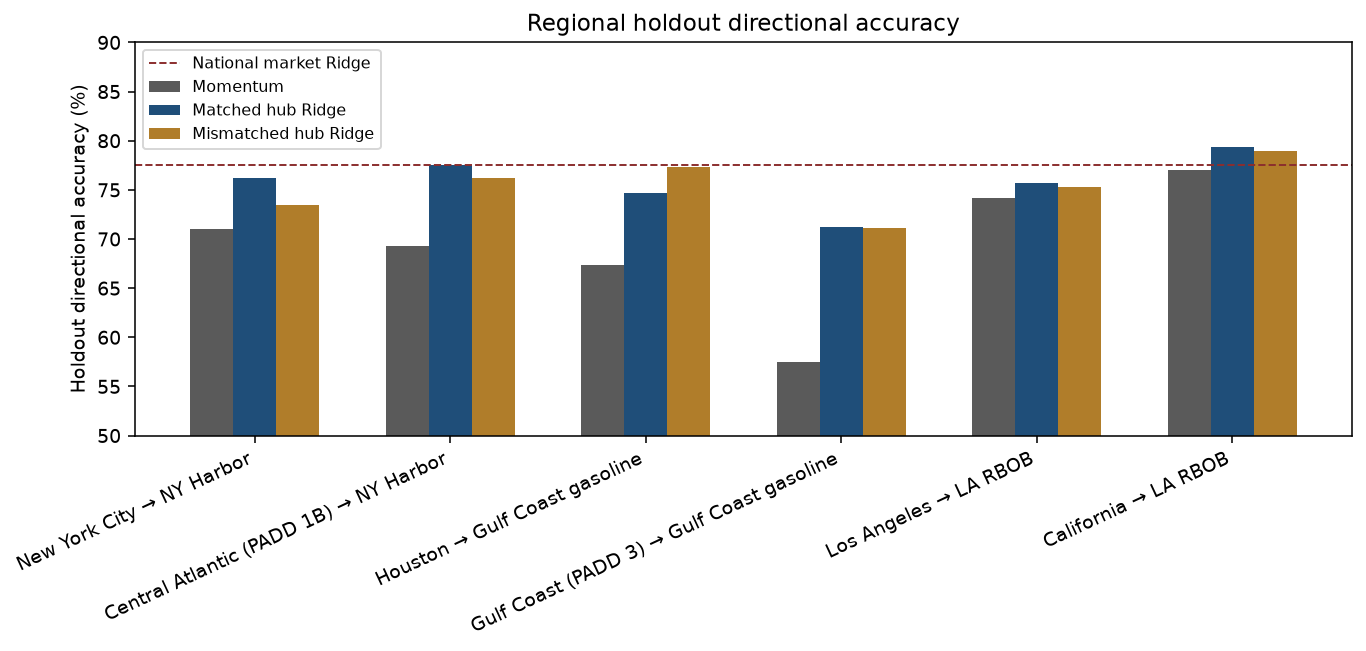

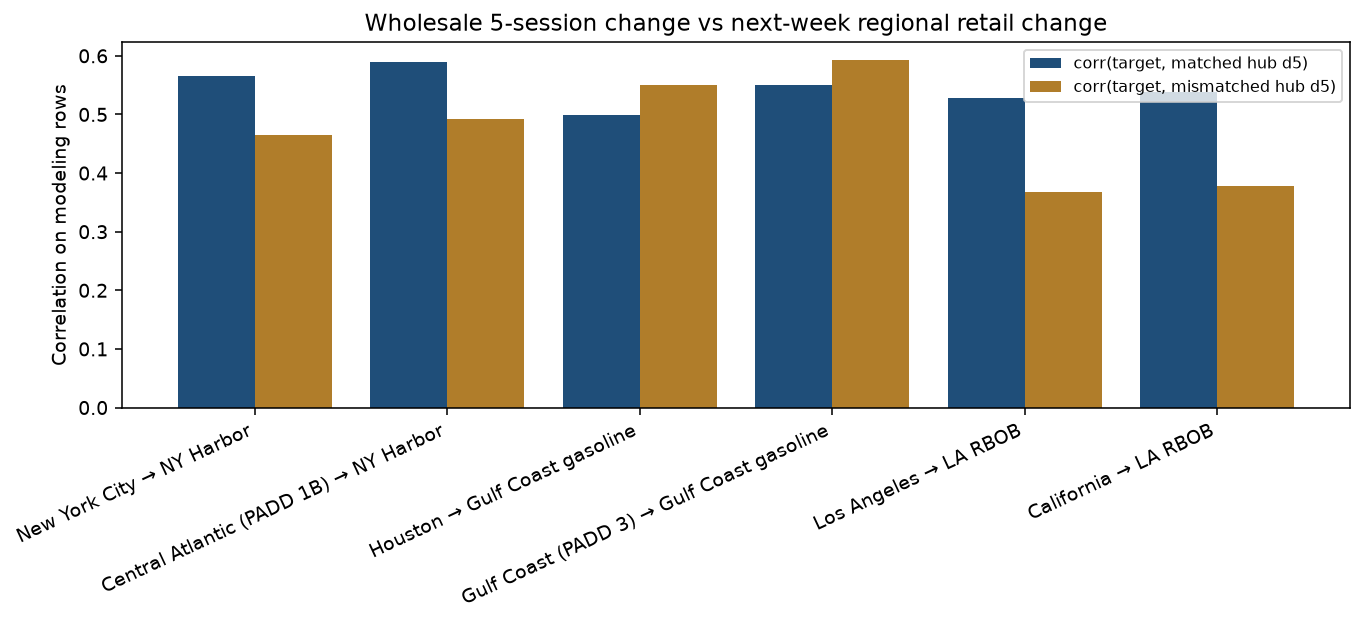

In [5]:
from matplotlib import image as mpimg
import matplotlib.pyplot as plt

fig_dir = ROOT / "reports" / "figures"
for name in [
    "regional_mae_by_region.png",
    "regional_diracc_by_region.png",
    "regional_passthrough_corr.png",
]:
    path = fig_dir / name
    print(path.relative_to(ROOT))
    img = mpimg.imread(path)
    plt.figure(figsize=(10, 4.4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)
    plt.close()


## Honest takeaways

1. EIA has 29 weekly regular retail geographies. Only six had a defensible match to NY Harbor, Gulf Coast, or LA RBOB.
2. **PADD 1B → NY Harbor** is the only matched model that beats national MAE (2.73¢ vs 2.93¢). Direction is ~the same (77.6% vs 77.5%).
3. **California** has the highest direction (79.3%), but momentum was already 77%. Markets barely add.
4. Matching **raises pass-through correlation** on the coasts where the spec differs (Harbor vs Gulf for the Northeast; RBOB vs Harbor for CA/LA).
5. Matching **fails on the Gulf**: NY Harbor tracks Houston/PADD 3 weekly retail as well or better than Gulf Coast spot. Do not force that map.
6. City EIA series are often *noisier* than the U.S. average. This is not a 3-day local product.
7. First city MVP: **New York City + NY Harbor**. Second: **Los Angeles + LA RBOB**. Not PADD 3 or PADD 5.
